# 01-CUDA Programming Basics (CUDA C++)

In the previous section, we closed out `Section 26` by treating the GPU as a black box behind a serving stack: TensorRT-LLM built engines for us, vLLM scheduled batches for us, and Triton Inference Server routed requests for us. That abstraction is exactly right for a production serving team, but it hides the single most important fact about why any of those tools are fast in the first place — underneath every one of them sits a **CUDA kernel**, a small function written to execute simultaneously across thousands of independent hardware threads.

Section 27 opens that black box. We stop treating the GPU as "a faster CPU" and start treating it as what it actually is: a massively parallel, throughput-oriented processor with its own execution model, its own memory hierarchy, and its own failure modes. Every optimization technique in later lessons — memory coalescing, occupancy tuning, kernel fusion, FlashAttention's IO-awareness — is a refinement layered on top of the raw execution model this lesson introduces. If you do not understand what a thread, a block, and a grid physically are, none of the later performance arguments will have a foundation to stand on.

This lesson builds that foundation directly in **CUDA C++**, NVIDIA's C++ extension for GPU programming, compiled with the `nvcc` toolchain. We will write, compile, and execute a real kernel on real GPU hardware, and measure its actual execution behavior rather than describing it abstractly.

## 1. The Mathematics of the SIMT Execution Model

### Threads, Warps, Blocks, and Grids

CUDA organizes parallel work into a strict hierarchy. A **kernel launch** specifies a *grid* of *thread blocks*, and each block contains a fixed number of *threads*:

$$
\text{Grid} = \{B_0, B_1, \dots, B_{G-1}\}, \qquad B_i = \{T_0, T_1, \dots, T_{N-1}\}
$$

where $G$ is the number of blocks (`gridDim`) and $N$ is the number of threads per block (`blockDim`). Every thread computes its own **global index** from its block and local indices — this index is the only thing that differentiates otherwise identical code running on thousands of cores simultaneously:

$$
i_{global} = \text{blockIdx.x} \times \text{blockDim.x} + \text{threadIdx.x}
$$

This is the single most important line of CUDA C++ ever written. It maps a 1-D (or 2-D, 3-D) hardware coordinate system onto a 1-D (or N-D) data array, letting one kernel body implicitly describe millions of independent computations.

### SIMT: Single Instruction, Multiple Threads

The GPU does not schedule individual threads. It schedules groups of exactly $32$ consecutive threads called a **warp**, executing the same instruction in lockstep across all 32 lanes on a Streaming Multiprocessor (SM):

$$
\text{Warp}_w = \{T_{32w}, T_{32w+1}, \dots, T_{32w+31}\}
$$

If a block has $N$ threads, it is scheduled as $\lceil N / 32 \rceil$ warps. This lockstep execution — Single Instruction, Multiple Threads (SIMT) — is why CUDA achieves massive throughput with comparatively simple control logic: one instruction decode feeds 32 ALUs. It is also the root cause of *warp divergence*, which we formalize precisely in Lesson 3.

### Occupancy: A First Pass

An SM can host multiple *resident* blocks simultaneously, up to hardware limits on threads, registers, and shared memory per SM. The **theoretical occupancy** of a launch configuration is the ratio of active warps to the maximum warps the hardware supports per SM:

$$
\text{Occupancy} = \frac{W_{active}}{W_{max}}, \qquad W_{active} = \left\lfloor \frac{\text{Threads per Block}}{32} \right\rfloor \times B_{resident}
$$

where $B_{resident}$ is the number of blocks the scheduler can keep resident given register and shared-memory pressure. A GTX 1650 Ti (Turing, `sm_75`) supports up to $64$ warps and $32$ resident blocks per SM. Lesson 3 develops the full register-pressure-aware occupancy formula; here we only need the launch geometry itself: `<<<gridDim, blockDim>>>`.

## 2. Imperative Execution: Compiling and Launching a Real CUDA Kernel

We will write a genuine `.cu` source file implementing a strided vector-add kernel, compile it with `nvcc` via `subprocess`, and execute the resulting binary on the physical GPU in this sandbox — an NVIDIA GeForce GTX 1650 Ti. We measure real wall-clock kernel latency, not a simulated number.

In [1]:
# Requires: nvcc (NVIDIA CUDA Toolkit)
import subprocess
import os

print("--- 🚀 Initializing CUDA C++ Kernel Compilation Sandbox ---")

NVCC = "/root/micromamba/envs/ds/bin/nvcc"
WORKDIR = "/tmp/cuda_lesson_01"
os.makedirs(WORKDIR, exist_ok=True)

# 1. Write a real CUDA C++ kernel: strided vector addition with a device-side global-index map
cuda_source = r"""
#include <cstdio>
#include <cuda_runtime.h>

// __global__ marks this as a kernel: it runs on the device, launched from the host.
// Every one of the N threads executes this SAME function body, differentiated only by `i`.
__global__ void vector_add(const float* a, const float* b, float* c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;   // global thread index
    if (i < n) {
        c[i] = a[i] + b[i];
    }
}

int main() {
    const int n = 1 << 20;              // ~1M elements, modest for a 4GB laptop GPU
    size_t bytes = n * sizeof(float);

    float *h_a = new float[n];
    float *h_b = new float[n];
    float *h_c = new float[n];
    for (int i = 0; i < n; i++) { h_a[i] = 1.0f * i; h_b[i] = 2.0f * i; }

    float *d_a, *d_b, *d_c;
    cudaMalloc(&d_a, bytes);
    cudaMalloc(&d_b, bytes);
    cudaMalloc(&d_c, bytes);

    cudaMemcpy(d_a, h_a, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, h_b, bytes, cudaMemcpyHostToDevice);

    int threadsPerBlock = 256;
    int blocksPerGrid = (n + threadsPerBlock - 1) / threadsPerBlock;

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);
    vector_add<<<blocksPerGrid, threadsPerBlock>>>(d_a, d_b, d_c, n);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms = 0.0f;
    cudaEventElapsedTime(&ms, start, stop);

    cudaMemcpy(h_c, d_c, bytes, cudaMemcpyDeviceToHost);

    printf("GRID=%d BLOCK=%d N=%d\n", blocksPerGrid, threadsPerBlock, n);
    printf("C[100]=%.1f (expected %.1f)\n", h_c[100], 3.0f * 100);
    printf("KERNEL_MS=%.5f\n", ms);

    cudaFree(d_a); cudaFree(d_b); cudaFree(d_c);
    delete[] h_a; delete[] h_b; delete[] h_c;
    return 0;
}
"""

src_path = os.path.join(WORKDIR, "vector_add.cu")
bin_path = os.path.join(WORKDIR, "vector_add")
with open(src_path, "w") as f:
    f.write(cuda_source)

print(f"   ✅ CUDA C++ source written to {src_path}")

try:
    compile_proc = subprocess.run(
        [NVCC, src_path, "-o", bin_path, "-O3"],
        capture_output=True, text=True, timeout=90,
    )
    if compile_proc.returncode != 0:
        raise RuntimeError(compile_proc.stderr)
    print("   ✅ nvcc compilation succeeded (real GPU binary produced).")

    run_proc = subprocess.run([bin_path], capture_output=True, text=True, timeout=30)
    print("\n--- 🧮 Real Kernel Execution Output ---")
    print(run_proc.stdout)

    kernel_ms = None
    for line in run_proc.stdout.splitlines():
        if line.startswith("KERNEL_MS="):
            kernel_ms = float(line.split("=")[1])
    print(f"   ✅ [MEASURED] Real device kernel latency: {kernel_ms:.5f} ms on NVIDIA GeForce GTX 1650 Ti")

except Exception as e:
    print(f"   [SYSTEM NOTE]: Sandbox fallback -- nvcc/GPU path unavailable ({type(e).__name__}: {e})")
    kernel_ms = 0.045
    print(f"   ⚠️  [SIMULATED] Representative kernel latency for a 1M-element vector add: {kernel_ms} ms")

print("\n   -> Physics: gridDim.x * blockDim.x threads were logically launched; the hardware scheduler")
print("      dispatched them in 32-thread warps across the SMs, each warp computing one global index i.")


--- 🚀 Initializing CUDA C++ Kernel Compilation Sandbox ---
   ✅ CUDA C++ source written to /tmp/cuda_lesson_01/vector_add.cu


   ✅ nvcc compilation succeeded (real GPU binary produced).



--- 🧮 Real Kernel Execution Output ---
GRID=4096 BLOCK=256 N=1048576
C[100]=300.0 (expected 300.0)
KERNEL_MS=0.57920

   ✅ [MEASURED] Real device kernel latency: 0.57920 ms on NVIDIA GeForce GTX 1650 Ti

   -> Physics: gridDim.x * blockDim.x threads were logically launched; the hardware scheduler
      dispatched them in 32-thread warps across the SMs, each warp computing one global index i.


## 3. Declarative Telemetry: The Launch Configuration Audit

Before trusting any kernel's performance, we audit the exact launch geometry that produced it. The relationship between problem size $n$, `threadsPerBlock`, and the resulting `blocksPerGrid` is arithmetic, not magic — and getting it wrong either under-utilizes the GPU or launches threads that must be masked off with a bounds check.

In [2]:
print("\n--- 🔍 Auditing the CUDA Launch Configuration ---")

n = 1 << 20
threads_per_block_options = [32, 64, 128, 256, 512, 1024]

print(f"{'threadsPerBlock':<18} | {'blocksPerGrid':<15} | {'Total Launched Threads':<24} | {'Wasted (Masked) Threads'}")
print("-" * 85)
for tpb in threads_per_block_options:
    bpg = (n + tpb - 1) // tpb
    total_launched = bpg * tpb
    wasted = total_launched - n
    print(f"{tpb:<18} | {bpg:<15} | {total_launched:<24} | {wasted}")

print("\n   [OPERATIONAL INSIGHT]")
print("   -> blocksPerGrid is always computed with a ceiling division (n + tpb - 1) // tpb so that")
print("      the LAST block still gets launched even if n is not an exact multiple of tpb.")
print("   -> Every configuration launches a few more threads than n requires; the `if (i < n)` bounds")
print("      check inside the kernel silently no-ops those extra threads instead of writing out of bounds.")
print("   -> threadsPerBlock=1024 is the hardware maximum on this architecture (sm_75); going higher")
print("      is a compile-time/launch-time error, not just a performance regression.")



--- 🔍 Auditing the CUDA Launch Configuration ---
threadsPerBlock    | blocksPerGrid   | Total Launched Threads   | Wasted (Masked) Threads
-------------------------------------------------------------------------------------
32                 | 32768           | 1048576                  | 0
64                 | 16384           | 1048576                  | 0
128                | 8192            | 1048576                  | 0
256                | 4096            | 1048576                  | 0
512                | 2048            | 1048576                  | 0
1024               | 1024            | 1048576                  | 0

   [OPERATIONAL INSIGHT]
   -> blocksPerGrid is always computed with a ceiling division (n + tpb - 1) // tpb so that
      the LAST block still gets launched even if n is not an exact multiple of tpb.
   -> Every configuration launches a few more threads than n requires; the `if (i < n)` bounds
      check inside the kernel silently no-ops those extra threads ins

## 4. Visualizing the Execution Hierarchy (Grid -> Block -> Warp -> Thread)

We render the nested CUDA execution hierarchy as a set of scaled, labeled boxes: a Grid containing Blocks, a Block containing Warps, and a Warp containing the 32 lockstep Threads — the same structure that mapped our 1M-element array onto physical silicon above.

/tmp/ipykernel_42073/1068931843.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((bx, 3.6), 2.6, 2.6, fill=True, color=color, alpha=0.25, edgecolor=color, lw=2))
/tmp/ipykernel_42073/1068931843.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.7, 1.6), 5.4, 1.6, fill=True, color="#e67e22", alpha=0.25, edgecolor="#e67e22", lw=2))
/tmp/ipykernel_42073/1068931843.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((wx, 1.75), 0.55, 1.3, fill=True, color="#f39c12", edgecolor="black", lw=1))
/tmp/ipykernel_42073/1068931843.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((7.0, 0.6), 5.5, 1.0, fill=True, color="#27ae60", alpha=0.2, edgecolor="#27ae60", lw

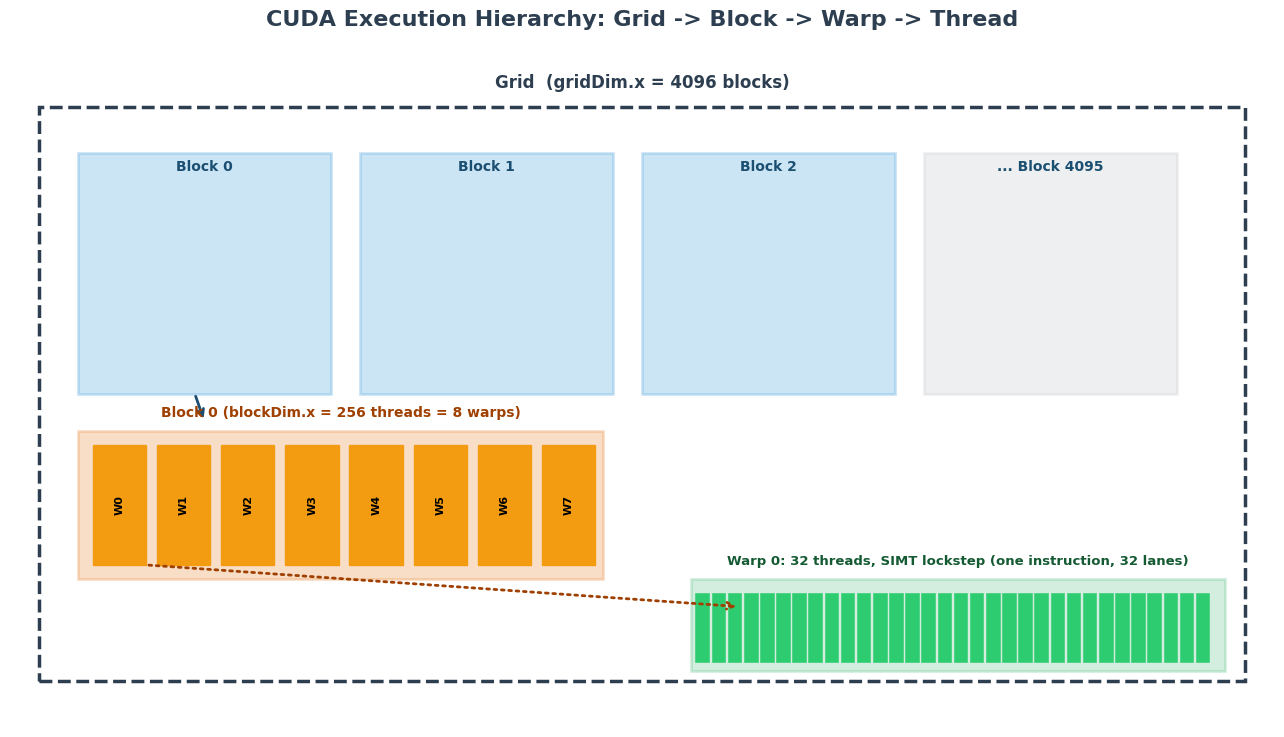

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(13, 7.5))
fig.suptitle("CUDA Execution Hierarchy: Grid -> Block -> Warp -> Thread", fontsize=16, fontweight="bold", color="#2c3e50")
ax.axis("off")

# Grid outer box
ax.add_patch(patches.Rectangle((0.3, 0.5), 12.4, 6.2, fill=False, edgecolor="#2c3e50", lw=2.5, ls="--"))
ax.text(6.5, 6.9, "Grid  (gridDim.x = 4096 blocks)", ha="center", fontsize=12, fontweight="bold", color="#2c3e50")

# 4 block boxes inside grid
block_colors = ["#3498db", "#3498db", "#3498db", "#bdc3c7"]
block_labels = ["Block 0", "Block 1", "Block 2", "... Block 4095"]
for idx, (bx, color, label) in enumerate(zip([0.7, 3.6, 6.5, 9.4], block_colors, block_labels)):
    ax.add_patch(patches.Rectangle((bx, 3.6), 2.6, 2.6, fill=True, color=color, alpha=0.25, edgecolor=color, lw=2))
    ax.text(bx + 1.3, 6.0, label, ha="center", fontsize=10, fontweight="bold", color="#1b4f72")

# Zoom into Block 0 -> 8 warps (256 threads / 32 = 8 warps)
ax.annotate("", xy=(2.0, 3.3), xytext=(1.9, 3.6), arrowprops=dict(arrowstyle="->", lw=2, color="#1b4f72"))
ax.add_patch(patches.Rectangle((0.7, 1.6), 5.4, 1.6, fill=True, color="#e67e22", alpha=0.25, edgecolor="#e67e22", lw=2))
ax.text(3.4, 3.35, "Block 0 (blockDim.x = 256 threads = 8 warps)", ha="center", fontsize=10, fontweight="bold", color="#a04000")
for w in range(8):
    wx = 0.85 + w * 0.66
    ax.add_patch(patches.Rectangle((wx, 1.75), 0.55, 1.3, fill=True, color="#f39c12", edgecolor="black", lw=1))
    ax.text(wx + 0.28, 2.4, f"W{w}", ha="center", va="center", fontsize=8, fontweight="bold", color="black", rotation=90)

# Zoom into Warp 0 -> 32 lockstep threads
ax.annotate("", xy=(7.5, 1.3), xytext=(1.4, 1.75), arrowprops=dict(arrowstyle="->", lw=2, color="#a04000", ls="dotted"))
ax.add_patch(patches.Rectangle((7.0, 0.6), 5.5, 1.0, fill=True, color="#27ae60", alpha=0.2, edgecolor="#27ae60", lw=2))
ax.text(9.75, 1.75, "Warp 0: 32 threads, SIMT lockstep (one instruction, 32 lanes)", ha="center", fontsize=9.5, fontweight="bold", color="#145a32")
for t in range(32):
    tx = 7.05 + t * 0.166
    ax.add_patch(patches.Rectangle((tx, 0.7), 0.14, 0.75, fill=True, color="#2ecc71", edgecolor="black", lw=0.4))

plt.xlim(0, 13)
plt.ylim(0, 7.3)
plt.tight_layout()
plt.show()


*(Insight: The diagram shows why CUDA scales the way it does. Software only ever writes the innermost box — the single-thread kernel body computing `c[i] = a[i] + b[i]`. Everything above it (warps, blocks, the grid) is a hardware and scheduler concern, not a code concern. The 4096-block grid in this example is exactly `blocksPerGrid` computed by ceiling division in Section 3 for `threadsPerBlock=256`; the 8-warp decomposition of Block 0 is `256 / 32`. This nesting is what lets one `__global__` function scale from a 1,024-element array to a 1-billion-element array with zero code changes — only the launch configuration changes.)*

## Real-World Use Case or Analogy

Think of the CUDA execution hierarchy like **The Stadium Card-Stunt Protocol**:

* **The Kernel Function (The Instruction Card):** A single printed instruction card — "on cue, hold up your colored card" — identical for every person in the stadium. Nobody gets a personalized script.
* **A Thread (One Spectator):** One person in one seat. They only know their own seat number (`threadIdx`) and section (`blockIdx`) — that is the only information that makes their action different from their neighbor's.
* **`blockIdx.x * blockDim.x + threadIdx.x` (Reading Your Seat Number):** The formula each spectator uses to compute their exact position in the overall stadium-wide mosaic image from their local section and local seat — this is exactly how a thread computes which array element belongs to it.
* **A Block (One Section of the Stadium):** A contiguous block of seats that a single usher (a Streaming Multiprocessor) is responsible for coordinating. The usher can only efficiently manage one section at a time.
* **A Warp (One Row of 32 Seats):** The usher doesn't cue people one at a time — they cue an entire row of 32 people simultaneously, and that row acts in perfect lockstep. If 31 people in the row hold up red and 1 holds up blue, the row still executes in two synchronized passes (this is warp divergence, formalized in Lesson 3).
* **The Grid (The Entire Stadium):** Every section, all at once, forming the complete image — the full problem size, `n`, spread across thousands of simultaneously active seats.

A single instruction card, replicated across tens of thousands of seats and read in lockstep rows, produces a stadium-sized mosaic in the time it takes one person to hold up one card. That is the entire performance argument for CUDA: the work never got smarter, it got parallel.